# **EC Sprint 3 — Machine Learning: Análise Exploratória de Dados (AED)**
## Projeto: Prazo 60 — Monitoramento do cumprimento da Lei dos 60 dias no tratamento oncológico de câncer de mama (Estado de São Paulo)

**Curso:** Tecnologia em Artificial Intelligence, Analytics, Cloud & Data Platforms

**Integrantes do grupo:**
* AMANDA BARRAL  — RM 569662
* EDUARDO BAMBULIM  — RM 573228
* GABRIELA CAVALCANTI — RM 568972
* JÚLIA FURIATI — RM 570547
* LÍVIA OLIVEIRA — RM 573963



---


## 1. Contexto e Objetivo do Projeto

### 1.1 O problema de negócio — "Prazo 60"

A **Lei nº 12.732/2012** determina que todo paciente com diagnóstico confirmado de câncer maligno
tem direito a iniciar o primeiro tratamento oncológico em **até 60 dias** a partir da data do
diagnóstico, dentro do Sistema Único de Saúde (SUS). O não cumprimento desse prazo está associado
a piores desfechos clínicos, principalmente em neoplasias de crescimento rápido, como é o caso de
parte dos casos de câncer de mama (CID-10 **C50**).

O nosso projeto ("Prazo 60") tem como objetivo de negócio **identificar, monitorar e antecipar**
os casos com maior risco de **não cumprir esse prazo legal**, permitindo que a gestão em saúde
atue preventivamente (ex.: priorização de agenda, apoio logístico ao deslocamento do paciente,
alocação de recursos entre regiões de saúde) antes que o prazo se esgote.

### 1.2 Fonte dos dados

Os dados utilizados neste projeto são públicos e derivados do ecossistema de informações em saúde
do Ministério da Saúde / DATASUS, especificamente da ferramenta **PAINEL-Oncologia**, desenvolvida
pelo INCA (Instituto Nacional de Câncer) e pelo Ministério da Saúde para monitorar o intervalo
entre o diagnóstico de uma neoplasia maligna e o início do tratamento oncológico no SUS
(Atty et al., 2020, *Revista Brasileira de Cancerologia*). O PAINEL-Oncologia é construído a
partir do relacionamento determinístico de informações do Sistema de Informação Ambulatorial
(SIA/BPA-i/APAC) e do Sistema de Informação Hospitalar (SIH/SUS), usando o Cartão Nacional de
Saúde e o diagnóstico de neoplasia como chave de ligação entre os registros — por isso o grupo
já vinha se referenciando ao TABNET/TABWIN e ao SIH/SUS como parte do universo de dados que
alimenta essas bases.

**Importante (limitação documentada pela própria literatura da ferramenta):** como o PAINEL-Oncologia
depende do relacionamento de múltiplos sistemas de registro, a qualidade da informação está sujeita
a inconsistências de digitação e de relacionamento entre bases — isso é algo que **de fato
identificamos e vamos evidenciar neste notebook** (ver seção de qualidade de dados / outliers).

### 1.3 As três bases de dados recebidas

| Arquivo | Granularidade | O que representa |
|---|---|---|
| `POBR_SP_Mama_Tratado.xlsx` | 1 linha = 1 caso de paciente com tratamento | Base principal: pacientes com câncer de mama (C50) tratadas no estado de SP, com datas de diagnóstico/tratamento e a variável-alvo do projeto (cumprimento ou não da Lei dos 60 dias) |
| `codigos_municipios_regioes.xlsx` | 1 linha = 1 município de SP | Tabela de dimensão geográfica/administrativa (Região Administrativa, Região Metropolitana, DRS — Departamento Regional de Saúde, Região de Saúde) |
| `RAW_PAINEL_ONCOLOGIA_consolidado.xlsx` | 1 linha = 1 (município × mês × indicador) | Indicadores nacionais do PAINEL-Oncologia (todos os municípios do Brasil), com métricas de cobertura de rastreamento/exames e produção hospitalar oncológica ao longo do tempo |

O objetivo desta seção do projeto é **unificar essas três bases** em um único dataset analítico
por chave de município + ano, construir o **dicionário de dados**, e realizar a **AED completa**
exigida pelo enunciado, preparando o terreno para a modelagem preditiva das próximas sprints.


## 2. Preparação do Ambiente e Carregamento dos Dados

A célula abaixo instala/importa as bibliotecas necessárias e carrega os três arquivos.

**Como rodar no Google Colab:**
1. Rode a célula de importação de bibliotecas.
2. Rode a célula de carregamento — ela vai detectar automaticamente que você está no Colab e
   abrir uma janela para você selecionar os 3 arquivos `.xlsx` do seu computador
   (`codigos_municipios_regioes.xlsx`, `RAW_PAINEL_ONCOLOGIA_consolidado.xlsx` e
   `POBR_SP_Mama_Tratado.xlsx`). Selecione os três de uma vez.
3. Alternativamente, se preferir usar o Google Drive, deixamos comentado no código um bloco pronto
   para montar o Drive e ler de uma pasta — basta descomentar e ajustar o caminho.


In [11]:
# ==========================================================
# 2.1 Bibliotecas
# ==========================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

SEED = 42
np.random.seed(SEED)

print('Bibliotecas carregadas com sucesso.')

Bibliotecas carregadas com sucesso.


In [12]:
# ==========================================================
# 2.2 Carregamento dos arquivos (Colab: upload manual | Drive: opcional | Local: já na pasta)
# ==========================================================
import os

ARQ_MUNICIPIOS = 'codigos_municipios_regioes.xlsx'
ARQ_PAINEL_RAW = 'RAW_PAINEL_ONCOLOGIA_consolidado.xlsx'
ARQ_POBR = 'POBR_SP_Mama_Tratado.xlsx'

arquivos_necessarios = [ARQ_MUNICIPIOS, ARQ_PAINEL_RAW, ARQ_POBR]

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    faltantes = [a for a in arquivos_necessarios if not os.path.exists(a)]
    if faltantes:
        print('Faça o upload dos seguintes arquivos (selecione todos de uma vez):')
        print(faltantes)
        from google.colab import files
        uploaded = files.upload()
    else:
        print('Arquivos já presentes no ambiente Colab.')

    # --- OPCIONAL: ler direto do Google Drive em vez de upload manual ---
    # from google.colab import drive
    # drive.mount('/content/drive')
    # PASTA_DRIVE = '/content/drive/MyDrive/CAMINHO/PARA/SEUS/ARQUIVOS/'
    # ARQ_MUNICIPIOS = PASTA_DRIVE + ARQ_MUNICIPIOS
    # ARQ_PAINEL_RAW = PASTA_DRIVE + ARQ_PAINEL_RAW
    # ARQ_POBR = PASTA_DRIVE + ARQ_POBR
else:
    print('Ambiente local detectado — assumindo que os 3 arquivos já estão na pasta de trabalho.')

for a in arquivos_necessarios:
    caminho = a if IN_COLAB else a
    status = 'OK' if os.path.exists(caminho) else 'AUSENTE'
    print(f'{status:8s} -> {caminho}')

Arquivos já presentes no ambiente Colab.
OK       -> codigos_municipios_regioes.xlsx
OK       -> RAW_PAINEL_ONCOLOGIA_consolidado.xlsx
OK       -> POBR_SP_Mama_Tratado.xlsx


In [13]:
# ==========================================================
# 2.3 Leitura das três bases
# ==========================================================
df_municipios = pd.read_excel(ARQ_MUNICIPIOS)
df_painel_raw = pd.read_excel(ARQ_PAINEL_RAW)
df_pobr = pd.read_excel(ARQ_POBR)

print('df_municipios:', df_municipios.shape)
print('df_painel_raw:', df_painel_raw.shape)
print('df_pobr      :', df_pobr.shape)

df_municipios: (647, 11)
df_painel_raw: (367638, 21)
df_pobr      : (46181, 29)


In [14]:
df_pobr.head()

In [15]:
df_municipios.head()

,cod_ibge,municipio,area_km,cod_ra,ra,cod_rm,rm,cod_drs,drs,cod_r_saude,r_saude
0,35,Estado de São Paulo,248219.480,NaN,Estado de São Paulo,NaN,Estado de São Paulo,NaN,Estado de São Paulo,NaN,Estado de São Paulo
1,3500000,Sem especificação de município,NaN,NaN,Sem especificação de município,NaN,Sem especificação de município,NaN,Sem especificação de município,NaN,Sem especificação de município
2,3500105,Adamantina,411.987,11.0,RA Presidente Prudente,99.0,Demais municípios,5.0,DRS Marília,35091.0,Adamantina
3,3500204,Adolfo,211.055,9.0,RA São José do Rio Preto,9.0,RM São José do Rio Preto,15.0,DRS São José do Rio Preto,35156.0,José Bonifácio
4,3500303,Aguaí,474.554,6.0,RA Campinas,99.0,Demais municípios,14.0,DRS São João da Boa Vista,35142.0,Mantiqueira


In [16]:
df_painel_raw.head()

,FONTE_ARQUIVO,CO_ANOMES,CO_IBGE,NO_MUNICIPIO,SG_UF,NO_UF,CO_REGIAO_SAUDE,NO_REGIAO_SAUDE,CO_MACRO,NO_MACRO,VL_INDICADOR_CALCULADO_MUN,VL_INDICADOR_CALCULADO_RS,VL_INDICADOR_CALCULADO_MS,VL_INDICADOR_CALCULADO_UF,VL_INDICADOR_CALCULADO_REG,VL_INDICADOR_CALCULADO_BR,VL_INDICADOR_CALCULADO_AL,DT_COMPETENCIA,DT_ATUALIZACAO,DS_UNIDADE_MEDIDA,DATA_REFERENCIA
0,ccmsrch,202605,110001,Alta Floresta D'Oeste,RO,Rondônia,11005,Zona da Mata,1101,Macrorregional II(Cacoal),0.0,0,0,0,15,50,20,2026-05-01 12:00:00,2026-08-07 11:07:37,Número,2026-08-07
1,ccmsrch,202605,110002,Ariquemes,RO,Rondônia,11001,Vale do Jamari,1102,Macrorregião I - Porto Velho,0.0,0,0,0,15,50,20,2026-05-01 12:00:00,2026-08-07 11:07:37,Número,2026-08-07
2,ccmsrch,202605,110003,Cabixi,RO,Rondônia,11006,Cone Sul,1101,Macrorregional II(Cacoal),0.0,0,0,0,15,50,20,2026-05-01 12:00:00,2026-08-07 11:07:37,Número,2026-08-07
3,ccmsrch,202605,110004,Cacoal,RO,Rondônia,11002,Café,1101,Macrorregional II(Cacoal),0.0,0,0,0,15,50,20,2026-05-01 12:00:00,2026-08-07 11:07:37,Número,2026-08-07
4,ccmsrch,202605,110005,Cerejeiras,RO,Rondônia,11006,Cone Sul,1101,Macrorregional II(Cacoal),0.0,0,0,0,15,50,20,2026-05-01 12:00:00,2026-08-07 11:07:37,Número,2026-08-07




### 3.1 Base principal — `df_pobr` (nível paciente/caso)

Colunas relevantes:
- **Identificação temporal:** `ANO_DIAGN`, `ANOMES_DIA`, `ANO_TRATAM`, `ANOMES_TRA`, `DT_DIAG`, `DT_TRAT`, `DT_NASC`
- **Identificação geográfica:** `UF_RESID`/`MUN_RESID` (onde a paciente mora), `UF_TRATAM`/`MUN_TRATAM` (onde foi tratada), `UF_DIAGN`/`MUN_DIAG` (onde foi diagnosticada)
- **Clínicas:** `TRATAMENTO`/`DS_TRATAMENTO` (tipo de 1º tratamento), `DIAGNOSTIC`/`DIAG_DETH` (sempre C50 — filtro já aplicado), `IDADE`, `SEXO` (sempre F), `ESTADIAM`/`DS_ESTADIAMENTO` (estágio do tumor), `FAIXA_ETARIA`
- **Desfecho (alvo do projeto):** `TEMPO_TRAT` (dias entre diagnóstico e tratamento) e `DS_CUMPRE_LEI_60_DIAS` (Sim/Não)
- **Contexto:** `DS_DESLOCAMENTO_MUNICIPAL` (se a paciente precisou se deslocar de município para ser tratada), `CNES_DIAG`/`CNES_TRAT` (estabelecimentos), `ARQUIVO_ORIGEM` (arquivo/ano de extração)

**Validações que fizemos ao inspecionar a base (importantes para justificar decisões abaixo):**
1. `CNS_PAC` está **100% ausente** (0 valores preenchidos) — é um identificador de paciente que veio
   completamente vazio na extração; não carrega nenhuma informação e será descartado.
2. `DIAGNOSTIC`, `DIAG_DETH` (sempre "C50") e `SEXO` (sempre "F") são **colunas constantes** — não
   têm variância nenhuma. Isso confirma que a base já veio filtrada exclusivamente para casos de
   câncer de mama em mulheres, mas também significa que essas colunas não têm poder discriminante
   para uma futura modelagem (variância zero).
3. Confirmamos matematicamente que `TEMPO_TRAT = (DT_TRAT − DT_DIAG).days` para 100% dos registros,
   e que `DS_CUMPRE_LEI_60_DIAS = "Sim"` sempre que `TEMPO_TRAT <= 60`, para 100% dos registros. Ou
   seja, **a variável-alvo é inteiramente derivada de `TEMPO_TRAT`**, que por sua vez é derivada de
   `DT_DIAG` e `DT_TRAT`. Isso é essencial para não cometer *data leakage* em uma futura modelagem
   (não se pode usar `TEMPO_TRAT` como feature para prever `DS_CUMPRE_LEI_60_DIAS` — seria usar a
   resposta para prever a própria resposta).


In [17]:
# ==========================================================
# 3.2 Limpeza da base principal (df_pobr)
# ==========================================================
df = df_pobr.copy()

# (a) Remover coluna 100% ausente e sem utilidade analítica
print('CNS_PAC — % ausente:', df['CNS_PAC'].isna().mean() * 100, '%')
df = df.drop(columns=['CNS_PAC'])

# (b) Conversão de datas (formato brasileiro dd/mm/aaaa)
df['DT_DIAG'] = pd.to_datetime(df['DT_DIAG'], format='%d/%m/%Y', errors='coerce')
df['DT_TRAT'] = pd.to_datetime(df['DT_TRAT'], format='%d/%m/%Y', errors='coerce')
df['DT_NASC'] = pd.to_datetime(df['DT_NASC'], format='%d/%m/%Y', errors='coerce')

print('\\nDatas não convertidas (NaT) após parsing:')
print(df[['DT_DIAG', 'DT_TRAT', 'DT_NASC']].isna().sum())

# (c) Verificação da consistência do TEMPO_TRAT (mostrado na justificativa acima)
diff_calc = (df['DT_TRAT'] - df['DT_DIAG']).dt.days
print('\\nTEMPO_TRAT == (DT_TRAT - DT_DIAG) em 100% dos casos?', (diff_calc == df['TEMPO_TRAT']).mean() == 1.0)

# (d) Flag de qualidade: TEMPO_TRAT negativo (tratamento registrado ANTES do diagnóstico -> inconsistência)
df['FLAG_TEMPO_INVALIDO'] = df['TEMPO_TRAT'] < 0
n_invalido = df['FLAG_TEMPO_INVALIDO'].sum()
print(f'\\nRegistros com TEMPO_TRAT negativo (inconsistência de datas): {n_invalido} ({n_invalido/len(df)*100:.2f}%)')

# (e) Versão binária da variável-alvo, útil para correlações/estatísticas
df['CUMPRE_60_DIAS_BIN'] = (df['DS_CUMPRE_LEI_60_DIAS'] == 'Sim').astype(int)

print('\\nShape após limpeza inicial:', df.shape)

CNS_PAC — % ausente: 100.0 %
\nDatas não convertidas (NaT) após parsing:
DT_DIAG    0
DT_TRAT    0
DT_NASC    0
dtype: int64
\nTEMPO_TRAT == (DT_TRAT - DT_DIAG) em 100% dos casos? True
\nRegistros com TEMPO_TRAT negativo (inconsistência de datas): 765 (1.66%)
\nShape após limpeza inicial: (46181, 30)


### 3.2 Base de dimensão geográfica — `df_municipios`

Esta base traz, para cada município do estado de São Paulo, sua Região Administrativa (RA),
Região Metropolitana (RM), DRS (Departamento Regional de Saúde) e Região de Saúde — informações
administrativas relevantes para entender **desigualdades regionais de acesso** ao tratamento.

O código de município (`cod_ibge`) está no padrão IBGE de 7 dígitos. Já nas bases de tratamento
(`MUN_RESID`, `MUN_TRATAM`, `MUN_DIAG`) e no painel oncológico (`CO_IBGE`), o código de município
usado é o **código reduzido do SUS/DATASUS, de 6 dígitos** (os 6 primeiros dígitos do código IBGE,
sem o dígito verificador). Validamos essa correspondência manualmente antes de prosseguir — por
exemplo, o código `355030` do `MUN_TRATAM` corresponde exatamente aos 6 primeiros dígitos do
código IBGE `3550308` (São Paulo capital) em `df_municipios`.


In [18]:
# ==========================================================
# 3.3 Padronização da chave de município (6 dígitos SUS <- 7 dígitos IBGE)
# ==========================================================
df_municipios['cod_ibge_6'] = df_municipios['cod_ibge'].astype(str).str[:6].astype(int)

# Exemplo de validação da chave
exemplo = df_municipios[df_municipios['cod_ibge_6'] == 355030][['cod_ibge', 'municipio', 'cod_ibge_6']]
print('Validação da chave de 6 dígitos (exemplo São Paulo capital):')
print(exemplo)

# Tabela enxuta para os merges (evita trazer colunas duplicadas/irrelevantes)
mun_small = df_municipios[['cod_ibge_6', 'municipio', 'area_km', 'ra', 'rm', 'drs', 'r_saude']].drop_duplicates('cod_ibge_6')
print('\\nTabela de município pronta para merge:', mun_small.shape)

Validação da chave de 6 dígitos (exemplo São Paulo capital):
     cod_ibge  municipio  cod_ibge_6
564   3550308  São Paulo      355030
\nTabela de município pronta para merge: (647, 7)


### 3.3 Base nacional de indicadores — `df_painel_raw`

Esta base traz, para **todos os municípios do Brasil**, um histórico mensal/anual de 6 tipos de
indicadores do PAINEL-Oncologia (coluna `FONTE_ARQUIVO`), relacionados a cobertura de rastreamento
e produção assistencial em oncologia (ex.: exames de rastreamento de câncer de mama e colo do
útero por faixa etária, registros hospitalares). Por ter granularidade de **município × mês ×
indicador**, ela está em um nível de agregação diferente da base principal (que é por paciente),
e por isso funciona como uma **base de contexto/macro-indicadores**, e não como registros
individuais de pacientes.

**Decisões de tratamento:**
1. Filtramos apenas municípios de **São Paulo (`SG_UF == 'SP'`)**, para manter coerência com o
   escopo do projeto (`UF_TRATAM` é 100% SP na base principal).
2. Extraímos o **ano** a partir de `CO_ANOMES` (formato `AAAAMM`), pois a base principal usa o
   ano do tratamento (`ANO_TRATAM`) como granularidade temporal, e não o mês.
3. Fizemos um **pivot** para transformar os 6 tipos de indicador (que estavam empilhados em
   linhas, no formato *long*) em colunas (formato *wide*), com uma linha por (`município`, `ano`).
   Isso é necessário para poder unir essa base à base principal por chave de município + ano.


In [19]:
# ==========================================================
# 3.4 Preparação da base de indicadores (filtro SP + pivot long->wide)
# ==========================================================
painel_sp = df_painel_raw[df_painel_raw['SG_UF'] == 'SP'].copy()
painel_sp['ANO'] = painel_sp['CO_ANOMES'].astype(str).str[:4].astype(int)

print('Tipos de indicador disponíveis (FONTE_ARQUIVO):')
print(painel_sp['FONTE_ARQUIVO'].unique())

painel_pivot = painel_sp.pivot_table(
    index=['CO_IBGE', 'ANO'],
    columns='FONTE_ARQUIVO',
    values='VL_INDICADOR_CALCULADO_MUN',
    aggfunc='mean'
).reset_index()
painel_pivot.columns.name = None

painel_pivot = painel_pivot.rename(columns={'CO_IBGE': 'MUN_TRATAM', 'ANO': 'ANO_TRATAM'})
# Prefixo CTX_ (contexto) para deixar claro que são variáveis agregadas de município, não do paciente
cols_indicadores = [c for c in painel_pivot.columns if c not in ('MUN_TRATAM', 'ANO_TRATAM')]
painel_pivot = painel_pivot.rename(columns={c: f'CTX_{c}' for c in cols_indicadores})

print('\\nBase de contexto pronta para merge:', painel_pivot.shape)
painel_pivot.head()

Tipos de indicador disponíveis (FONTE_ARQUIVO):
['ccmsrch' 'ccmsdmh' 'ccmhpersus' 'ccmhhcac' 'ccmec50a69' 'ccmec25a64']
\nBase de contexto pronta para merge: (7095, 8)


,MUN_TRATAM,ANO_TRATAM,CTX_ccmec25a64,CTX_ccmec50a69,CTX_ccmhhcac,CTX_ccmhpersus,CTX_ccmsdmh,CTX_ccmsrch
0,350010,2016,0.0,736.0,0.0,0.0,0.0,0.0
1,350010,2017,0.0,1113.0,0.0,0.0,0.0,0.0
2,350010,2018,0.0,1211.0,0.0,0.0,0.0,0.0
3,350010,2019,0.0,1309.0,0.0,0.0,0.0,0.0
4,350010,2020,0.0,852.0,0.0,0.0,0.0,0.0


### 3.4 Construção do dataset unificado (join pelas chaves)

Agora unimos as três bases pela chave de município:
- `df_pobr` **+** `df_municipios` → por `MUN_TRATAM` (município de tratamento) **e** por `MUN_RESID`
  (município de residência), trazendo os atributos geográficos de ambos (por isso usamos os
  sufixos `_TRATAM` e `_RESID`).
- resultado **+** `painel_pivot` → por `MUN_TRATAM` **e** `ANO_TRATAM`, trazendo o contexto de
  indicadores oncológicos do município/ano em que a paciente foi tratada.




In [20]:
# ==========================================================
# 3.5 Merge final -> dataset unificado
# ==========================================================
geo_tratam = mun_small.add_suffix('_TRATAM').rename(columns={'cod_ibge_6_TRATAM': 'MUN_TRATAM'})
geo_resid = mun_small.add_suffix('_RESID').rename(columns={'cod_ibge_6_RESID': 'MUN_RESID'})

df = df.merge(geo_tratam, on='MUN_TRATAM', how='left')
df = df.merge(geo_resid, on='MUN_RESID', how='left')
print('Após merge geográfico:', df.shape)

df = df.merge(painel_pivot, on=['MUN_TRATAM', 'ANO_TRATAM'], how='left')
print('Após merge do contexto oncológico:', df.shape)

taxa_match_geo = df['municipio_TRATAM'].notna().mean()
taxa_match_ctx = df['CTX_ccmec50a69'].notna().mean()
print(f'\\nTaxa de casamento (match) geografia (TRATAM): {taxa_match_geo*100:.2f}%')
print(f'Taxa de casamento (match) contexto oncológico: {taxa_match_ctx*100:.2f}%')

taxa_match_geo_resid = df['municipio_RESID'].notna().mean()
print(f'Taxa de casamento (match) geografia (RESID): {taxa_match_geo_resid*100:.2f}%')
print('(Nem toda paciente reside em SP — algumas vêm de outros estados para tratamento; nesses')
print('casos o município de residência não existe na tabela de dimensão, que cobre apenas SP.')
print('Essa ausência é esperada e será tratada como categoria própria mais adiante.)')

Após merge geográfico: (46181, 42)
Após merge do contexto oncológico: (46181, 48)
\nTaxa de casamento (match) geografia (TRATAM): 100.00%
Taxa de casamento (match) contexto oncológico: 100.00%
Taxa de casamento (match) geografia (RESID): 96.14%
(Nem toda paciente reside em SP — algumas vêm de outros estados para tratamento; nesses
casos o município de residência não existe na tabela de dimensão, que cobre apenas SP.
Essa ausência é esperada e será tratada como categoria própria mais adiante.)


In [21]:
# ==========================================================
# 3.6 Dataset unificado final — visão geral
# ==========================================================
print('DIMENSÕES FINAIS DO DATASET UNIFICADO:', df.shape)
print()
print('Colunas:')
for c in df.columns:
    print(' -', c)

df.to_csv('dataset_unificado_prazo60.csv', index=False)
print('\\nDataset unificado salvo como dataset_unificado_prazo60.csv')

DIMENSÕES FINAIS DO DATASET UNIFICADO: (46181, 48)

Colunas:
 - ANO_DIAGN
 - ANOMES_DIA
 - ANO_TRATAM
 - ANOMES_TRA
 - UF_RESID
 - MUN_RESID
 - UF_TRATAM
 - MUN_TRATAM
 - UF_DIAGN
 - MUN_DIAG
 - TRATAMENTO
 - DIAGNOSTIC
 - IDADE
 - SEXO
 - ESTADIAM
 - CNES_DIAG
 - CNES_TRAT
 - TEMPO_TRAT
 - DIAG_DETH
 - DT_DIAG
 - DT_TRAT
 - DT_NASC
 - ARQUIVO_ORIGEM
 - DS_CUMPRE_LEI_60_DIAS
 - DS_DESLOCAMENTO_MUNICIPAL
 - DS_TRATAMENTO
 - DS_ESTADIAMENTO
 - FAIXA_ETARIA
 - FLAG_TEMPO_INVALIDO
 - CUMPRE_60_DIAS_BIN
 - municipio_TRATAM
 - area_km_TRATAM
 - ra_TRATAM
 - rm_TRATAM
 - drs_TRATAM
 - r_saude_TRATAM
 - municipio_RESID
 - area_km_RESID
 - ra_RESID
 - rm_RESID
 - drs_RESID
 - r_saude_RESID
 - CTX_ccmec25a64
 - CTX_ccmec50a69
 - CTX_ccmhhcac
 - CTX_ccmhpersus
 - CTX_ccmsdmh
 - CTX_ccmsrch
\nDataset unificado salvo como dataset_unificado_prazo60.csv


## 4. Dicionário de Dados

O dicionário abaixo documenta **todas as colunas do dataset unificado**, permitindo que qualquer
pessoa do time (ou um novo colaborador) entenda o significado, o tipo e a origem de cada variável
sem precisar consultar as bases originais.

**Convenção de prefixos usada no dataset unificado:**
- Sem prefixo → variável original da base de pacientes (`POBR_SP_Mama_Tratado`)
- `_TRATAM` → atributo geográfico do **município de tratamento** (vindo de `codigos_municipios_regioes`)
- `_RESID` → atributo geográfico do **município de residência** (vindo de `codigos_municipios_regioes`)
- `CTX_` → indicador de **contexto municipal/anual** (vindo de `RAW_PAINEL_ONCOLOGIA_consolidado`)


In [22]:
# ==========================================================
# 4.1 Dicionário de dados (gerado como DataFrame para fácil consulta/exportação)
# ==========================================================
dicionario = [
    # --- Identificação temporal ---
    ('ANO_DIAGN', 'int', 'Base pacientes', 'Ano do diagnóstico da neoplasia'),
    ('ANOMES_DIA', 'int', 'Base pacientes', 'Ano e mês do diagnóstico (formato AAAAMM)'),
    ('ANO_TRATAM', 'int', 'Base pacientes', 'Ano do início do 1º tratamento'),
    ('ANOMES_TRA', 'int', 'Base pacientes', 'Ano e mês do início do tratamento (formato AAAAMM)'),
    ('DT_DIAG', 'datetime', 'Base pacientes', 'Data completa do diagnóstico'),
    ('DT_TRAT', 'datetime', 'Base pacientes', 'Data completa do início do 1º tratamento'),
    ('DT_NASC', 'datetime', 'Base pacientes', 'Data de nascimento da paciente'),
    ('ARQUIVO_ORIGEM', 'texto (categórico)', 'Base pacientes', 'Identificador do arquivo/ano de extração original (POBR2022 a POBR2026)'),

    # --- Identificação geográfica (códigos SUS, 6 dígitos) ---
    ('UF_RESID', 'int (código)', 'Base pacientes', 'Código da UF de residência da paciente (35 = SP)'),
    ('MUN_RESID', 'int (código SUS, 6 díg.)', 'Base pacientes', 'Código do município de residência da paciente'),
    ('UF_TRATAM', 'int (código)', 'Base pacientes', 'Código da UF onde o tratamento ocorreu (sempre 35 = SP)'),
    ('MUN_TRATAM', 'int (código SUS, 6 díg.)', 'Base pacientes', 'Código do município onde o tratamento ocorreu'),
    ('UF_DIAGN', 'int (código)', 'Base pacientes', 'Código da UF de diagnóstico'),
    ('MUN_DIAG', 'int (código SUS, 6 díg.)', 'Base pacientes', 'Código do município de diagnóstico'),

    # --- Clínicas ---
    ('TRATAMENTO', 'int (código)', 'Base pacientes', 'Código numérico do tipo de 1º tratamento (1=Cirurgia,2=Quimio,3=Radio,4=Outros)'),
    ('DS_TRATAMENTO', 'texto (categórico)', 'Base pacientes', 'Descrição do tipo de 1º tratamento'),
    ('DIAGNOSTIC', 'int (constante)', 'Base pacientes', 'Código do tipo de diagnóstico (constante=1; base já filtrada)'),
    ('DIAG_DETH', 'texto (constante)', 'Base pacientes', 'CID-10 do diagnóstico (constante = "C50", câncer de mama)'),
    ('SEXO', 'texto (constante)', 'Base pacientes', 'Sexo da paciente (constante = "F")'),
    ('IDADE', 'int', 'Base pacientes', 'Idade da paciente na data do diagnóstico (anos)'),
    ('FAIXA_ETARIA', 'texto (categórico ordinal)', 'Base pacientes', 'Faixa etária agrupada (<40 / 40-49 / 50-69 / 70+)'),
    ('ESTADIAM', 'int (código)', 'Base pacientes', 'Código numérico do estágio do tumor (0 a 4; 5="Não se Aplica")'),
    ('DS_ESTADIAMENTO', 'texto (categórico ordinal)', 'Base pacientes', 'Estágio do tumor por extenso (Estágio 0 a IV, ou "Não se Aplica")'),
    ('CNES_DIAG', 'int (código)', 'Base pacientes', 'Código CNES do estabelecimento de saúde onde ocorreu o diagnóstico'),
    ('CNES_TRAT', 'int (código)', 'Base pacientes', 'Código CNES do estabelecimento de saúde onde ocorreu o tratamento'),

    # --- Alvo do projeto ---
    ('TEMPO_TRAT', 'int (dias)', 'Base pacientes (derivada)', 'Nº de dias entre diagnóstico e início do tratamento = (DT_TRAT - DT_DIAG). Pode ser negativo por inconsistência de registro (ver seção de qualidade de dados)'),
    ('DS_CUMPRE_LEI_60_DIAS', 'texto (binário)', 'Base pacientes (derivada)', '"Sim" se TEMPO_TRAT <= 60, "Não" caso contrário — VARIÁVEL-ALVO do projeto'),
    ('CUMPRE_60_DIAS_BIN', 'int (0/1)', 'Derivada neste notebook', 'Versão numérica de DS_CUMPRE_LEI_60_DIAS (1=Sim, 0=Não), para uso em correlações/modelagem'),
    ('FLAG_TEMPO_INVALIDO', 'bool', 'Derivada neste notebook', 'True quando TEMPO_TRAT < 0 (inconsistência de datas na fonte)'),

    # --- Contexto adicional ---
    ('DS_DESLOCAMENTO_MUNICIPAL', 'texto (binário)', 'Base pacientes', '"Sim" se a paciente precisou se deslocar para um município diferente do de residência para ser tratada'),

    # --- Geografia (município de TRATAMENTO) ---
    ('municipio_TRATAM', 'texto', 'Dimensão município', 'Nome do município onde ocorreu o tratamento'),
    ('area_km_TRATAM', 'float', 'Dimensão município', 'Área territorial (km²) do município de tratamento'),
    ('ra_TRATAM', 'texto (categórico)', 'Dimensão município', 'Região Administrativa do município de tratamento'),
    ('rm_TRATAM', 'texto (categórico)', 'Dimensão município', 'Região Metropolitana do município de tratamento (ou "Demais municípios")'),
    ('drs_TRATAM', 'texto (categórico)', 'Dimensão município', 'Departamento Regional de Saúde (DRS) do município de tratamento'),
    ('r_saude_TRATAM', 'texto (categórico)', 'Dimensão município', 'Região de Saúde do município de tratamento'),

    # --- Geografia (município de RESIDÊNCIA) ---
    ('municipio_RESID', 'texto', 'Dimensão município', 'Nome do município de residência (NaN se a paciente reside fora de SP)'),
    ('area_km_RESID', 'float', 'Dimensão município', 'Área territorial (km²) do município de residência'),
    ('ra_RESID', 'texto (categórico)', 'Dimensão município', 'Região Administrativa do município de residência'),
    ('rm_RESID', 'texto (categórico)', 'Dimensão município', 'Região Metropolitana do município de residência'),
    ('drs_RESID', 'texto (categórico)', 'Dimensão município', 'DRS do município de residência'),
    ('r_saude_RESID', 'texto (categórico)', 'Dimensão município', 'Região de Saúde do município de residência'),

    # --- Contexto oncológico municipal/anual ---
    ('CTX_ccmec25a64', 'float', 'Painel oncológico (contexto)', 'Indicador municipal/anual de exames de rastreamento — mulheres 25 a 64 anos (colo do útero)'),
    ('CTX_ccmec50a69', 'float', 'Painel oncológico (contexto)', 'Indicador municipal/anual de exames de rastreamento — mulheres 50 a 69 anos (mama)'),
    ('CTX_ccmhhcac', 'float', 'Painel oncológico (contexto)', 'Indicador municipal/anual de produção hospitalar oncológica (registros hospitalares de câncer)'),
    ('CTX_ccmhpersus', 'float', 'Painel oncológico (contexto)', 'Indicador municipal/anual de procedimentos oncológicos registrados no SUS'),
    ('CTX_ccmsdmh', 'float', 'Painel oncológico (contexto)', 'Indicador municipal/anual relacionado a mamografias no SUS'),
    ('CTX_ccmsrch', 'float', 'Painel oncológico (contexto)', 'Indicador municipal/anual relacionado a rastreamento de câncer do colo do útero'),
]

df_dicionario = pd.DataFrame(dicionario, columns=['Coluna', 'Tipo', 'Origem', 'Descrição'])
print(f'Dicionário com {len(df_dicionario)} variáveis documentadas.')
df_dicionario

Dicionário com 48 variáveis documentadas.


,Coluna,Tipo,Origem,Descrição
0,ANO_DIAGN,int,Base pacientes,Ano do diagnóstico da neoplasia
1,ANOMES_DIA,int,Base pacientes,Ano e mês do diagnóstico (formato AAAAMM)
2,ANO_TRATAM,int,Base pacientes,Ano do início do 1º tratamento
3,ANOMES_TRA,int,Base pacientes,Ano e mês do início do tratamento (formato AAA...
4,DT_DIAG,datetime,Base pacientes,Data completa do diagnóstico
5,DT_TRAT,datetime,Base pacientes,Data completa do início do 1º tratamento
6,DT_NASC,datetime,Base pacientes,Data de nascimento da paciente
7,ARQUIVO_ORIGEM,texto (categórico),Base pacientes,Identificador do arquivo/ano de extração origi...
8,UF_RESID,int (código),Base pacientes,Código da UF de residência da paciente (35 = SP)
9,MUN_RESID,"int (código SUS, 6 díg.)",Base pacientes,Código do município de residência da paciente


In [23]:
# Exportar o dicionário de dados como CSV, para anexar ao relatório/entrega
df_dicionario.to_csv('dicionario_de_dados_prazo60.csv', index=False)
print('Dicionário salvo em dicionario_de_dados_prazo60.csv')

Dicionário salvo em dicionario_de_dados_prazo60.csv


 os nomes técnicos das 6 fontes de
> indicador do PAINEL-Oncologia (`ccmsrch`, `ccmsdmh`, `ccmhpersus`, `ccmhhcac`, `ccmec50a69`,
> `ccmec25a64`) não vêm acompanhados, nos arquivos brutos, de um dicionário oficial detalhado.
> A interpretação acima foi construída a partir (i) do nome técnico de cada arquivo-fonte,
> (ii) da faixa etária explícita no nome (25-64 = rastreamento de colo do útero; 50-69 =
> rastreamento de mama, que são as faixas etárias-alvo oficiais dos respectivos programas
> nacionais de rastreamento do INCA) e (iii) da ordem de grandeza dos valores observados. Essa é
> exatamente o tipo de **limitação de documentação da base** que o enunciado pede para identificarmos
> — e é um ponto que recomendamos esclarecer com a fonte de dados (INCA/DATASUS) antes de usar essas
> 6 colunas como variáveis explicativas em um modelo preditivo formal.


## 5. Análise Exploratória de Dados (AED)

### 5.1 Distribuição das variáveis

Vamos analisar a forma da distribuição das principais variáveis quantitativas (`IDADE` e
`TEMPO_TRAT`) e a frequência das principais variáveis categóricas, buscando identificar se alguma
delas se aproxima de uma distribuição conhecida (Normal, Exponencial etc.), e se há assimetrias
relevantes.


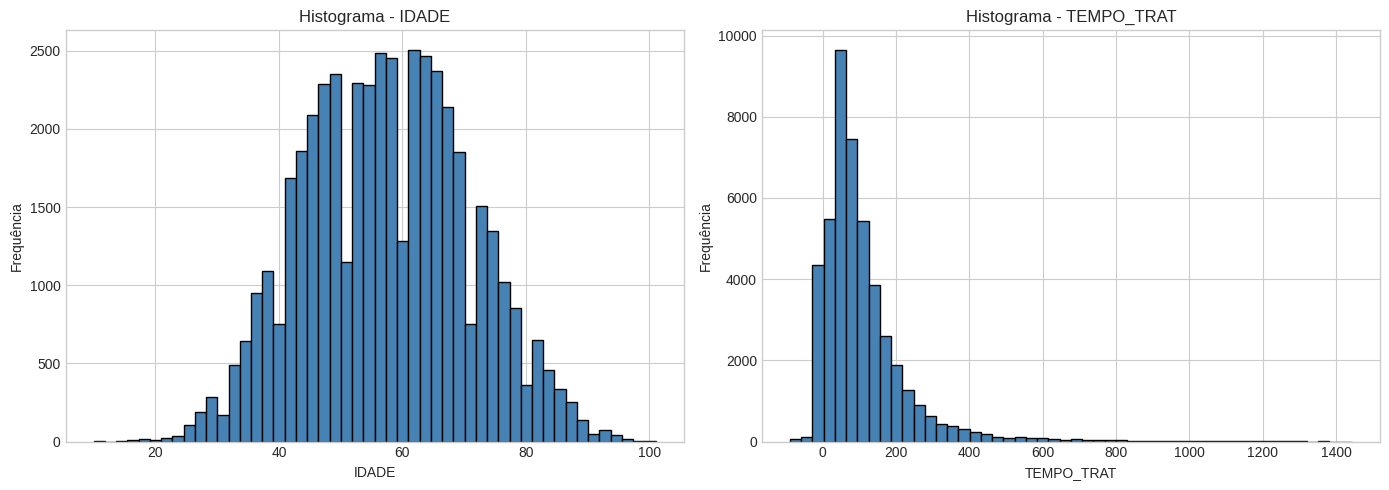

#### ASSIMETRIA (SKEWNESS) E CURTOSE ####
IDADE        | Skewness:   0.071 | Curtose:   -0.435
TEMPO_TRAT   | Skewness:   3.340 | Curtose:   17.838


In [24]:
# ==========================================================
# 5.1.1 Variáveis quantitativas — histogramas, assimetria e curtose
# ==========================================================
variaveis_quant = ['IDADE', 'TEMPO_TRAT']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col in zip(axes, variaveis_quant):
    ax.hist(df[col], bins=50, color='steelblue', edgecolor='black')
    ax.set_title(f'Histograma - {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequência')
plt.tight_layout()
plt.show()

print('#### ASSIMETRIA (SKEWNESS) E CURTOSE ####')
for col in variaveis_quant:
    print(f'{col:12s} | Skewness: {df[col].skew():7.3f} | Curtose: {df[col].kurt():8.3f}')

In [25]:
# ==========================================================
# 5.1.2 Teste de normalidade (Shapiro-Wilk em amostra, pois o teste é sensível a N grande)
# ==========================================================
np.random.seed(SEED)
n_amostra = min(5000, len(df))

print('#### TESTE DE SHAPIRO-WILK (H0: a variável segue distribuição Normal) ####')
for col in variaveis_quant:
    amostra = df[col].dropna().sample(n_amostra, random_state=SEED)
    stat, p_valor = stats.shapiro(amostra)
    conclusao = 'REJEITA H0 (não é Normal)' if p_valor < 0.05 else 'NÃO rejeita H0'
    print(f'{col:12s} | estatística={stat:.4f} | p-valor={p_valor:.2e} | {conclusao}')

#### TESTE DE SHAPIRO-WILK (H0: a variável segue distribuição Normal) ####
IDADE        | estatística=0.9964 | p-valor=1.08e-09 | REJEITA H0 (não é Normal)
TEMPO_TRAT   | estatística=0.7060 | p-valor=4.33e-69 | REJEITA H0 (não é Normal)


**Interpretação — Distribuição das variáveis**

- **`IDADE`** tem *skewness* próxima de zero (≈0,07) e curtose levemente negativa (≈-0,43), ou
  seja, sua forma é **aproximadamente simétrica**, parecida com uma Normal — o histograma confirma
  um formato de sino. Ainda assim, o teste de Shapiro-Wilk rejeita a hipótese de normalidade
  (p < 0,05). Isso é esperado e é uma **limitação conhecida do próprio teste**: com milhares de
  observações, o Shapiro-Wilk se torna extremamente sensível a pequenos desvios da normalidade que
  não têm relevância prática. Por isso, complementamos o teste formal com a análise visual e com
  skewness/curtose, que são mais informativas aqui: `IDADE` pode ser tratada como aproximadamente
  Normal para fins descritivos.

- **`TEMPO_TRAT`** apresenta *skewness* de aproximadamente **3,3** e curtose de aproximadamente
  **17,8** — fortemente assimétrica à direita e com caudas muito mais pesadas que a Normal. Isso
  reflete o próprio fenômeno estudado: a maioria das pacientes inicia o tratamento relativamente
  rápido (mediana bem abaixo da média), mas existe uma cauda de casos com atrasos muito longos
  (chegando a mais de 1.400 dias). Essa forma é característica de distribuições como a
  **Exponencial** ou **Log-Normal**, típicas de "tempos até um evento" (*time-to-event*), o que é
  coerente com a literatura de análise de sobrevivência/tempo até tratamento. Essa assimetria é
  também o motivo pelo qual a variável-alvo do projeto foi construída como uma **variável binária
  de corte** (cumpriu ou não os 60 dias) em vez de se basear diretamente na média de `TEMPO_TRAT`.


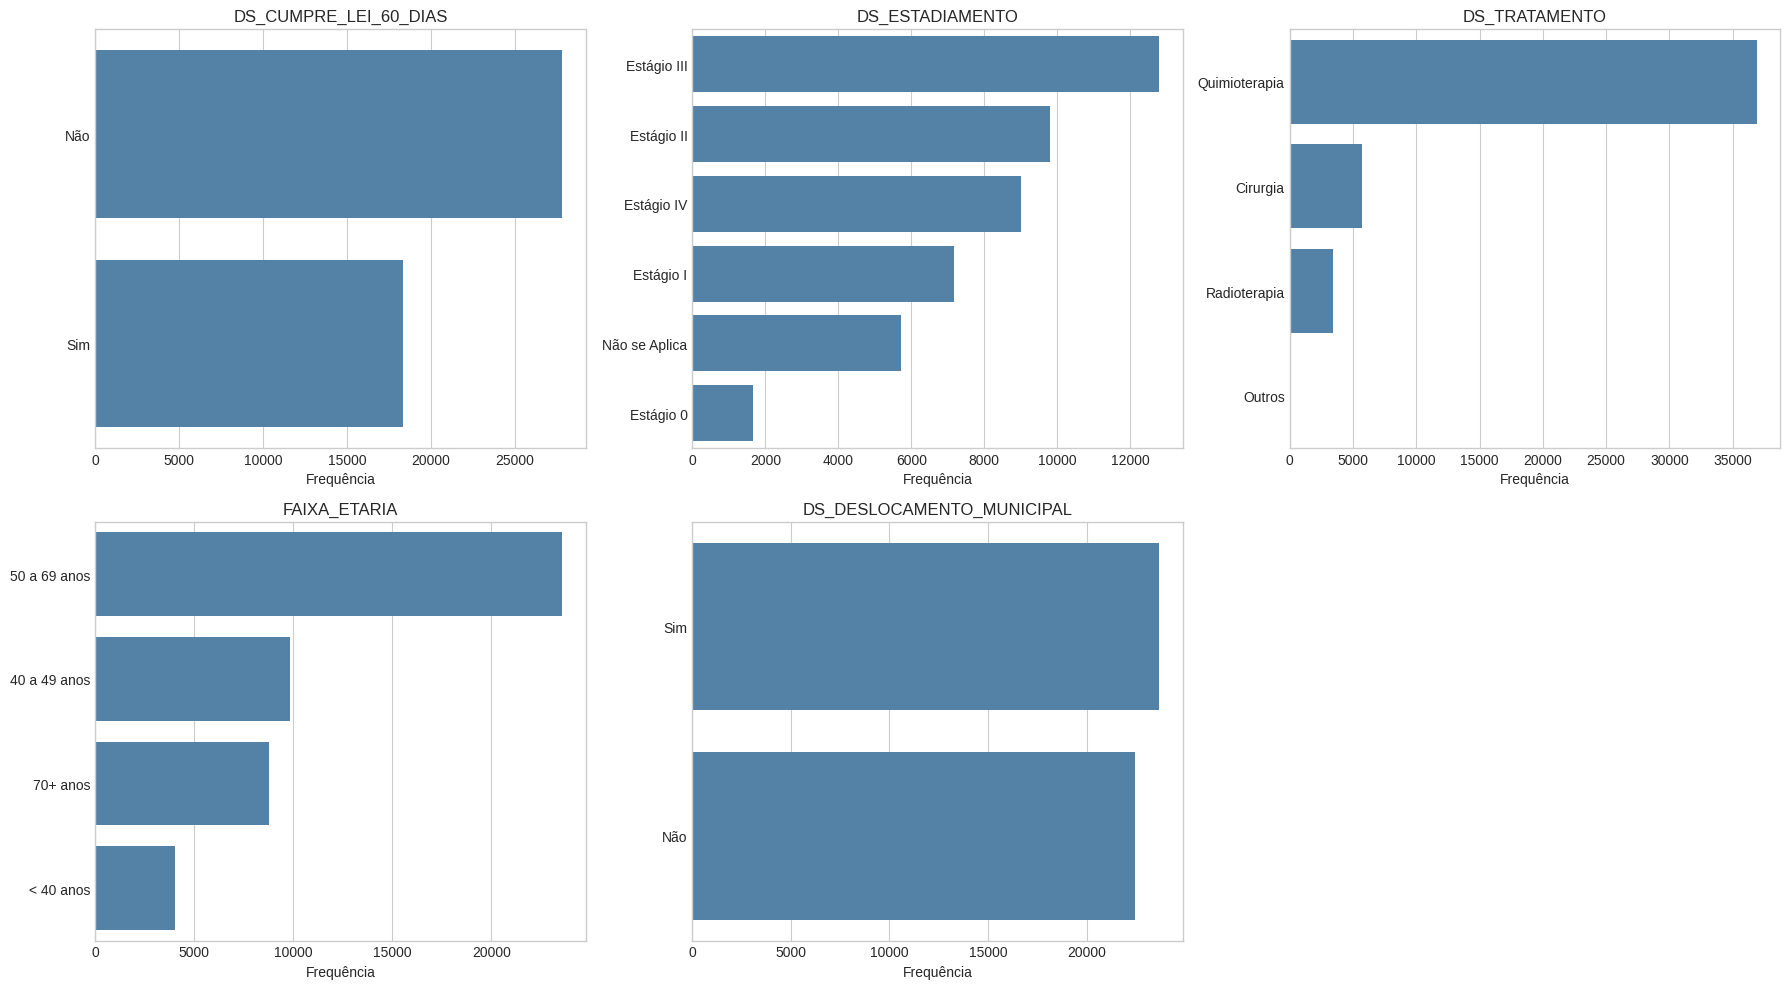

\n#### DS_CUMPRE_LEI_60_DIAS ####
DS_CUMPRE_LEI_60_DIAS
Não    60.26%
Sim    39.74%
Name: proportion, dtype: object
\n#### DS_ESTADIAMENTO ####
DS_ESTADIAMENTO
Estágio III      27.73%
Estágio II       21.24%
Estágio IV       19.52%
Estágio I         15.5%
Não se Aplica     12.4%
Estágio 0         3.61%
Name: proportion, dtype: object
\n#### DS_TRATAMENTO ####
DS_TRATAMENTO
Quimioterapia    79.87%
Cirurgia          12.4%
Radioterapia      7.49%
Outros            0.24%
Name: proportion, dtype: object
\n#### FAIXA_ETARIA ####
FAIXA_ETARIA
50 a 69 anos    51.05%
40 a 49 anos    21.24%
70+ anos        18.99%
< 40 anos        8.71%
Name: proportion, dtype: object
\n#### DS_DESLOCAMENTO_MUNICIPAL ####
DS_DESLOCAMENTO_MUNICIPAL
Sim    51.32%
Não    48.68%
Name: proportion, dtype: object


In [26]:
# ==========================================================
# 5.1.3 Variáveis categóricas — distribuição de frequência
# ==========================================================
variaveis_cat = ['DS_CUMPRE_LEI_60_DIAS', 'DS_ESTADIAMENTO', 'DS_TRATAMENTO',
                  'FAIXA_ETARIA', 'DS_DESLOCAMENTO_MUNICIPAL']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for ax, col in zip(axes, variaveis_cat):
    ordem = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=ordem, ax=ax, color='steelblue')
    ax.set_title(col)
    ax.set_xlabel('Frequência')
    ax.set_ylabel('')
axes[-1].axis('off')
plt.tight_layout()
plt.show()

for col in variaveis_cat:
    print(f'\\n#### {col} ####')
    print(df[col].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

**Interpretação — Variáveis categóricas**

O desfecho do projeto (`DS_CUMPRE_LEI_60_DIAS`) está **moderadamente desbalanceado**: cerca de
60% dos casos **não** cumprem o prazo de 60 dias, contra 40% que cumprem — algo relevante para a
próxima etapa de modelagem preditiva (pode exigir técnicas de balanceamento de classes).
`DS_TRATAMENTO` é dominado por Quimioterapia (~80% dos casos), o que é esperado clinicamente, já
que a quimioterapia costuma ser indicada em estágios mais avançados e/ou como parte de protocolos
combinados. `DS_ESTADIAMENTO` mostra concentração nos Estágios II e III, sinalizando que boa parte
dos diagnósticos não ocorre em fase inicial — um ponto de atenção em saúde pública. `FAIXA_ETARIA`
confirma o perfil epidemiológico esperado do câncer de mama, concentrado na faixa de 50 a 69 anos.


### 5.2 Medidas de localização e variabilidade


In [27]:
# ==========================================================
# 5.2.1 Tabela de medidas estatísticas — variáveis quantitativas
# ==========================================================
def calcular_medidas(serie):
    return pd.Series({
        'Média': serie.mean(),
        'Mediana': serie.median(),
        'Desvio Padrão': serie.std(),
        'Coef. de Variação (%)': (serie.std() / serie.mean()) * 100 if serie.mean() != 0 else np.nan,
        'Mínimo': serie.min(),
        'Q1 (25%)': serie.quantile(0.25),
        'Q3 (75%)': serie.quantile(0.75),
        'IQR (Q3-Q1)': serie.quantile(0.75) - serie.quantile(0.25),
        'Máximo': serie.max(),
    })

tabela_medidas = pd.DataFrame({col: calcular_medidas(df[col]) for col in variaveis_quant})
tabela_medidas.round(2)

,IDADE,TEMPO_TRAT
Média,57.41,109.94
Mediana,57.00,77.00
Desvio Padrão,13.29,123.80
Coef. de Variação (%),23.16,112.61
Mínimo,10.00,-89.00
Q1 (25%),47.00,39.00
Q3 (75%),67.00,141.00
IQR (Q3-Q1),20.00,102.00
Máximo,101.00,1443.00


**Interpretação — Medidas de localização e variabilidade**

Para `IDADE`, a média (≈57,4 anos) e a mediana (57 anos) estão muito próximas, reforçando a
simetria já observada, com desvio padrão de ≈13,3 anos e coeficiente de variação moderado
(≈23%) — dispersão razoável, mas sem grandes distorções.

Já para `TEMPO_TRAT`, a média (≈110 dias) é **bem maior** que a mediana (77 dias), com desvio
padrão altíssimo (≈124 dias) e coeficiente de variação acima de 100% — sinal claro de dispersão
elevada e de que a média **não é uma boa medida de tendência central** para essa variável (é
puxada para cima pela cauda de casos extremos). A mediana e o IQR (39 a 141 dias) descrevem melhor
o comportamento típico: metade dos casos inicia o tratamento entre 39 e 141 dias após o
diagnóstico — e mesmo o valor superior desse intervalo (141 dias) já ultrapassa os 60 dias
legais, o que por si só é um indício importante do tamanho do problema que o projeto pretende
enfrentar.


### 5.3 Valores Ausentes (Missing Values)


In [28]:
# ==========================================================
# 5.3.1 Panorama de valores ausentes no dataset unificado
# ==========================================================
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
tabela_missing = pd.DataFrame({'Qtd. ausente': missing, '% ausente': missing_pct})
tabela_missing = tabela_missing[tabela_missing['Qtd. ausente'] > 0].sort_values('% ausente', ascending=False)
print(f'Colunas com valores ausentes: {len(tabela_missing)} de {df.shape[1]}')
tabela_missing

Colunas com valores ausentes: 6 de 48


,Qtd. ausente,% ausente
municipio_RESID,1782,3.86
area_km_RESID,1782,3.86
ra_RESID,1782,3.86
rm_RESID,1782,3.86
drs_RESID,1782,3.86
r_saude_RESID,1782,3.86


**Interpretação — Valores ausentes**

Na base original de pacientes (`df_pobr`), a única coluna completamente ausente era `CNS_PAC`
(100% vazia), que já foi removida na etapa de limpeza (seção 3.2) — não havia estratégia de
imputação sensata para um identificador de paciente 100% vazio; a exclusão da coluna foi a decisão
correta e mais transparente.

Depois do processo de unificação, o **único bloco de ausência que sobrou** é o das colunas
`*_RESID` (município de residência): cerca de **3,9% dos registros** (aproximadamente 1.782 casos)
não encontram correspondência na tabela de dimensão de municípios de SP, porque **essas pacientes
residem em outros estados** e vieram para SP se tratar. Esse *missing* **não é um erro de
qualidade de dados** — é uma ausência estruturalmente esperada, já que a tabela de dimensão
(`codigos_municipios_regioes`) cobre apenas os municípios do estado de São Paulo.

**Estratégia de imputação proposta:** para as colunas geográficas `*_RESID`, **não recomendamos
imputação estatística** (preencher com média/moda faria pouco sentido para uma variável
categórica geográfica e introduziria viés). Em vez disso, propomos criar uma **categoria
explícita "Fora de SP / Não mapeado"**, preservando a informação real (a paciente não reside em
SP) em vez de mascará-la — isso também vira, por si só, uma variável potencialmente útil para a
modelagem (pacientes de outros estados podem ter um padrão de deslocamento e prazo diferente).


In [29]:
# ==========================================================
# 5.3.2 Tratamento proposto: categoria explícita para geografia de residência ausente
# ==========================================================
colunas_geo_resid_cat = ['municipio_RESID', 'ra_RESID', 'rm_RESID', 'drs_RESID', 'r_saude_RESID']
for col in colunas_geo_resid_cat:
    df[col] = df[col].fillna('Fora de SP / Não mapeado')

print('Após imputação categórica das colunas geográficas de residência:')
print(df[colunas_geo_resid_cat].isna().sum())

Após imputação categórica das colunas geográficas de residência:
municipio_RESID    0
ra_RESID           0
rm_RESID           0
drs_RESID          0
r_saude_RESID      0
dtype: int64


### 5.4 Outliers


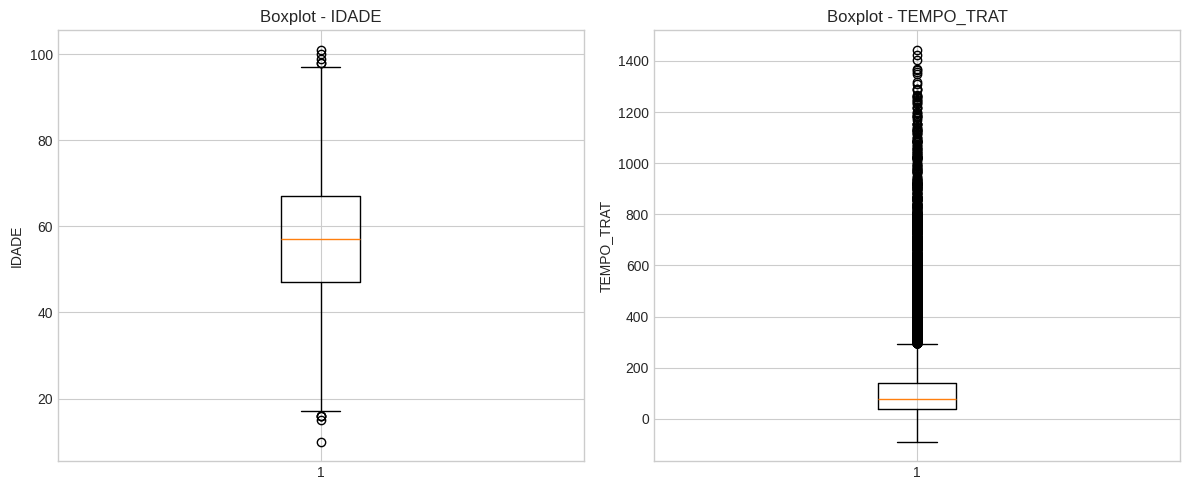

#### LIMITES DE OUTLIER (REGRA DO IQR — 1.5×IQR) ####
IDADE        | Q1=   47.00 Q3=   67.00 IQR=   20.00 | Limite inferior=    17.00 | Limite superior=    97.00 | Outliers=10 (0.02%)
TEMPO_TRAT   | Q1=   39.00 Q3=  141.00 IQR=  102.00 | Limite inferior=  -114.00 | Limite superior=   294.00 | Outliers=2794 (6.05%)


In [30]:
# ==========================================================
# 5.4.1 Boxplots e limites via IQR — IDADE e TEMPO_TRAT
# ==========================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, col in zip(axes, variaveis_quant):
    ax.boxplot(df[col].dropna())
    ax.set_title(f'Boxplot - {col}')
    ax.set_ylabel(col)
plt.tight_layout()
plt.show()

print('#### LIMITES DE OUTLIER (REGRA DO IQR — 1.5×IQR) ####')
limites = {}
for col in variaveis_quant:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    li, ls = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((df[col] < li) | (df[col] > ls)).sum()
    limites[col] = (li, ls)
    print(f'{col:12s} | Q1={q1:8.2f} Q3={q3:8.2f} IQR={iqr:8.2f} | Limite inferior={li:9.2f} | Limite superior={ls:9.2f} | Outliers={n_out} ({n_out/len(df)*100:.2f}%)')

In [31]:
# ==========================================================
# 5.4.2 Análise contextual dos outliers de TEMPO_TRAT
# ==========================================================
li_tempo, ls_tempo = limites['TEMPO_TRAT']

outliers_baixo = df[df['TEMPO_TRAT'] < li_tempo]
outliers_alto = df[df['TEMPO_TRAT'] > ls_tempo]

print(f'Outliers "baixos" (TEMPO_TRAT < {li_tempo:.0f} dias): {len(outliers_baixo)}')
print(f'  -> destes, {df["FLAG_TEMPO_INVALIDO"].sum()} são registros com TEMPO_TRAT NEGATIVO (inconsistência de data)')
print(f'Outliers "altos" (TEMPO_TRAT > {ls_tempo:.0f} dias): {len(outliers_alto)} ({len(outliers_alto)/len(df)*100:.2f}%)')
print()
print('Distribuição de DS_CUMPRE_LEI_60_DIAS entre os outliers "altos" (tratamentos muito demorados):')
print(outliers_alto['DS_CUMPRE_LEI_60_DIAS'].value_counts())
print()
print('Distribuição de DS_ESTADIAMENTO entre os outliers "altos":')
print(outliers_alto['DS_ESTADIAMENTO'].value_counts(normalize=True).mul(100).round(1))

Outliers "baixos" (TEMPO_TRAT < -114 dias): 0
  -> destes, 765 são registros com TEMPO_TRAT NEGATIVO (inconsistência de data)
Outliers "altos" (TEMPO_TRAT > 294 dias): 2794 (6.05%)

Distribuição de DS_CUMPRE_LEI_60_DIAS entre os outliers "altos" (tratamentos muito demorados):
DS_CUMPRE_LEI_60_DIAS
Não    2794
Name: count, dtype: int64

Distribuição de DS_ESTADIAMENTO entre os outliers "altos":
DS_ESTADIAMENTO
Estágio II       29.6
Estágio III      22.2
Estágio I        19.1
Estágio IV       18.9
Não se Aplica     6.3
Estágio 0         3.9
Name: proportion, dtype: float64


**Interpretação — Outliers de `TEMPO_TRAT`: por que NÃO vamos removê-los**

A regra do IQR identifica dois grupos de valores extremos em `TEMPO_TRAT`:

1. **Outliers baixos (negativos):** 765 registros (≈1,66% da base) em que `DT_TRAT` é anterior a
   `DT_DIAG` — isso é **fisicamente impossível** (não se pode tratar antes de diagnosticar) e
   representa um **erro de qualidade de dados**, provavelmente decorrente do relacionamento
   determinístico entre diferentes sistemas de origem do PAINEL-Oncologia (SIA e SIH), que a
   própria literatura da ferramenta reconhece como uma limitação. **Decisão:** esses registros
   foram marcados com a flag `FLAG_TEMPO_INVALIDO` (seção 3.2) em vez de excluídos da base — assim
   preservamos as demais informações do caso (idade, estágio, tratamento etc.), mas eles devem ser
   **excluídos de qualquer análise ou modelagem que dependa do valor numérico de `TEMPO_TRAT`**
   (ex.: regressão do tempo até tratamento), já que o valor informado é inválido.

2. **Outliers altos (>294 dias):** aproximadamente 6% da base — pacientes cujo tratamento demorou
   muito mais que o prazo legal. **Decisão: manter esses registros.** Diferente de um outlier
   típico (erro de medição), esses casos são **exatamente o fenômeno central que o projeto Prazo 60
   busca entender e prever** — descartá-los distorceria a análise ao remover justamente os casos de
   maior risco/maior interesse para o negócio. Note ainda que **100% desses casos extremos têm
   `DS_CUMPRE_LEI_60_DIAS = "Não"`**, o que é coerente e reforça a validade da variável-alvo.

Essa distinção — outlier como **erro** (deve ser tratado/sinalizado) versus outlier como
**fenômeno de interesse legítimo** (deve ser mantido) — é uma das decisões estatísticas mais
importantes deste projeto.


In [32]:
# ==========================================================
# 5.4.3 Comparação antes/depois do tratamento de TEMPO_TRAT (impacto na média)
# ==========================================================
media_antes = df['TEMPO_TRAT'].mean()
mediana_antes = df['TEMPO_TRAT'].median()

df_tempo_valido = df[~df['FLAG_TEMPO_INVALIDO']]
media_depois = df_tempo_valido['TEMPO_TRAT'].mean()
mediana_depois = df_tempo_valido['TEMPO_TRAT'].median()

print('#### IMPACTO DE REMOVER APENAS OS REGISTROS INVÁLIDOS (TEMPO_TRAT < 0) ####')
print(f'Média   antes: {media_antes:.2f} dias   | Média   depois: {media_depois:.2f} dias')
print(f'Mediana antes: {mediana_antes:.2f} dias | Mediana depois: {mediana_depois:.2f} dias')
print(f'\\n(Os outliers "altos", legítimos, foram mantidos em ambos os cálculos — só removemos os')
print('765 registros com data inconsistente, que representam menos de 2% da base.)')

#### IMPACTO DE REMOVER APENAS OS REGISTROS INVÁLIDOS (TEMPO_TRAT < 0) ####
Média   antes: 109.94 dias   | Média   depois: 112.06 dias
Mediana antes: 77.00 dias | Mediana depois: 79.00 dias
\n(Os outliers "altos", legítimos, foram mantidos em ambos os cálculos — só removemos os
765 registros com data inconsistente, que representam menos de 2% da base.)


**Interpretação:** remover apenas os 765 registros com `TEMPO_TRAT` negativo (inconsistência
de datas) praticamente não altera a média nem a mediana — o que é esperado, já que são poucos
registros (≈1,7%) e concentrados perto de zero. Isso confirma que essa limpeza é segura e não
distorce a análise, ao contrário do que aconteceria se removêssemos também os outliers altos
(que, como discutido, representam o próprio fenômeno de interesse do projeto).


### 5.5 Relações entre variáveis

Nesta seção investigamos padrões de associação entre variáveis — tanto entre variáveis
quantitativas (correlação), quanto entre variáveis categóricas e o desfecho do projeto
(testes de independência qui-quadrado), que é o tipo de relação mais relevante para as
próximas etapas de modelagem preditiva.


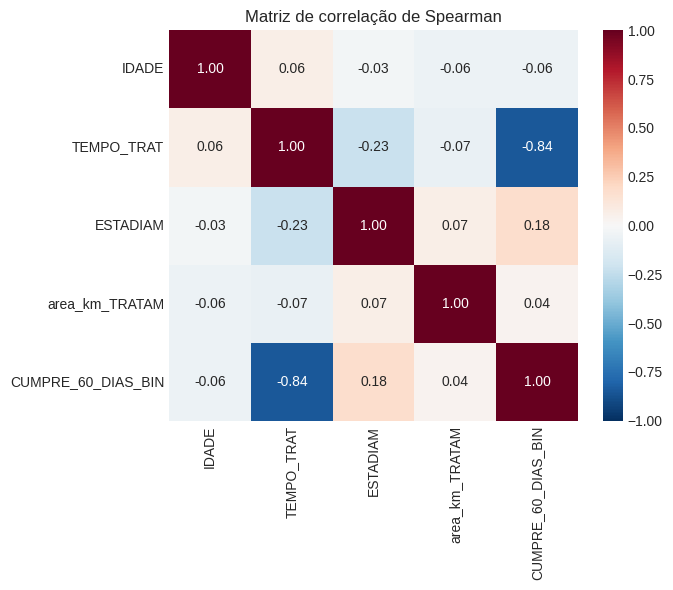

,IDADE,TEMPO_TRAT,ESTADIAM,area_km_TRATAM,CUMPRE_60_DIAS_BIN
IDADE,1.000,0.065,-0.028,-0.060,-0.058
TEMPO_TRAT,0.065,1.000,-0.226,-0.071,-0.844
ESTADIAM,-0.028,-0.226,1.000,0.065,0.179
area_km_TRATAM,-0.060,-0.071,0.065,1.000,0.036
CUMPRE_60_DIAS_BIN,-0.058,-0.844,0.179,0.036,1.000


In [33]:
# ==========================================================
# 5.5.1 Correlação entre variáveis quantitativas (Spearman)
# ==========================================================
# Usamos Spearman (e não Pearson) porque TEMPO_TRAT é fortemente assimétrico (seção 5.1),
# e Spearman mede associação monotônica sem exigir normalidade nem relação linear.
colunas_correlacao = ['IDADE', 'TEMPO_TRAT', 'ESTADIAM', 'area_km_TRATAM', 'CUMPRE_60_DIAS_BIN']
matriz_corr = df_tempo_valido[colunas_correlacao].corr(method='spearman')

plt.figure(figsize=(7, 6))
sns.heatmap(matriz_corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1)
plt.title('Matriz de correlação de Spearman')
plt.tight_layout()
plt.show()

matriz_corr.round(3)

**Interpretação — Correlações numéricas**

A correlação mais relevante é entre `ESTADIAM` e `TEMPO_TRAT` (Spearman ≈ **-0,26**): quanto
maior o código do estágio, menor tende a ser o tempo até o tratamento — à primeira vista isso
parece contraintuitivo (esperaríamos que estágios mais avançados fossem tratados com a mesma ou
maior agilidade). Uma leitura mais cuidadosa, porém, exige cautela: `ESTADIAM` **não é uma escala
puramente ordinal contínua** neste dataset — o valor "5" representa "Não se Aplica" (geralmente
associado a cirurgias e procedimentos que não dependem de estadiamento oncológico formal e que
tendem a ocorrer mais rapidamente), o que distorce a correlação linear/monotônica calculada dessa
forma. Por isso, complementamos essa leitura com a análise categórica abaixo (crosstab e
qui-quadrado), que é mais apropriada para essa variável.

As demais correlações (`IDADE`, `area_km_TRATAM`) com `TEMPO_TRAT` e com o desfecho são fracas
(|ρ| < 0,1), sugerindo que idade e tamanho territorial do município isoladamente não são bons
preditores lineares do cumprimento do prazo — o que não significa ausência de relação (relações
não-lineares ou em conjunto com outras variáveis podem existir e serão exploradas na modelagem).


#### TABELA DE CONTINGÊNCIA (contagens) ####
DS_CUMPRE_LEI_60_DIAS   Não   Sim
DS_ESTADIAMENTO                  
Estágio 0              1138   530
Estágio I              5393  1767
Estágio II             6950  2860
Estágio III            6786  6019
Estágio IV             5441  3572
Não se Aplica          2122  3603
\n#### TABELA DE CONTINGÊNCIA (% dentro de cada estágio) ####
DS_CUMPRE_LEI_60_DIAS   Não   Sim
DS_ESTADIAMENTO                  
Estágio 0              68.2  31.8
Estágio I              75.3  24.7
Estágio II             70.8  29.2
Estágio III            53.0  47.0
Estágio IV             60.4  39.6
Não se Aplica          37.1  62.9
\nTeste Qui-quadrado: estatística=2749.98 | gl=5 | p-valor=0.00e+00
Conclusão: existe associação estatisticamente significativa (p<0.05)


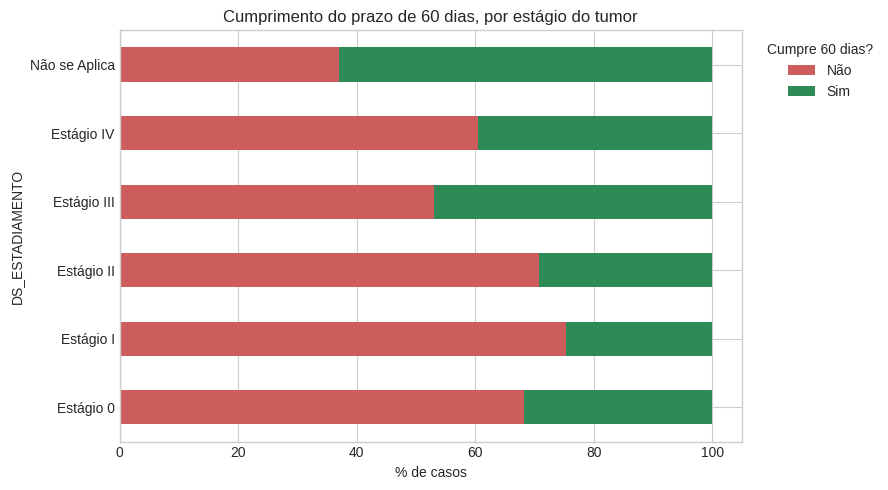

In [34]:
# ==========================================================
# 5.5.2 Estágio do tumor x Cumprimento do prazo de 60 dias (categórica x categórica)
# ==========================================================
tabela_estadiam = pd.crosstab(df['DS_ESTADIAMENTO'], df['DS_CUMPRE_LEI_60_DIAS'])
tabela_estadiam_pct = pd.crosstab(df['DS_ESTADIAMENTO'], df['DS_CUMPRE_LEI_60_DIAS'], normalize='index').mul(100).round(1)

chi2, p_valor, gl, esperado = stats.chi2_contingency(tabela_estadiam)

print('#### TABELA DE CONTINGÊNCIA (contagens) ####')
print(tabela_estadiam)
print('\\n#### TABELA DE CONTINGÊNCIA (% dentro de cada estágio) ####')
print(tabela_estadiam_pct)
print(f'\\nTeste Qui-quadrado: estatística={chi2:.2f} | gl={gl} | p-valor={p_valor:.2e}')
print('Conclusão:', 'existe associação estatisticamente significativa (p<0.05)' if p_valor < 0.05 else 'não há evidência de associação')

fig, ax = plt.subplots(figsize=(9, 5))
tabela_estadiam_pct.plot(kind='barh', stacked=True, ax=ax, color=['indianred', 'seagreen'])
ax.set_xlabel('% de casos')
ax.set_title('Cumprimento do prazo de 60 dias, por estágio do tumor')
ax.legend(title='Cumpre 60 dias?', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Interpretação:** o teste qui-quadrado confirma associação estatisticamente significativa
(p < 0,001) entre estágio do tumor e cumprimento do prazo. O achado mais importante do ponto de
vista de negócio: pacientes em **Estágio IV** (o mais avançado) têm uma das **piores** taxas de
cumprimento do prazo (≈40% cumprem, contra ≈60% de descumprimento) — justamente o grupo que mais
se beneficiaria de um início rápido de tratamento. Já os casos classificados como "Não se Aplica"
(em geral, cirurgias diretas, sem estadiamento oncológico formal) têm a **melhor** taxa de
cumprimento (≈63%), reforçando que a via cirúrgica tende a ser operacionalmente mais rápida que a
via quimio/radioterápica dentro do fluxo assistencial observado.


In [35]:
# ==========================================================
# 5.5.3 Deslocamento municipal x Cumprimento do prazo de 60 dias
# ==========================================================
tabela_desloc = pd.crosstab(df['DS_DESLOCAMENTO_MUNICIPAL'], df['DS_CUMPRE_LEI_60_DIAS'])
tabela_desloc_pct = pd.crosstab(df['DS_DESLOCAMENTO_MUNICIPAL'], df['DS_CUMPRE_LEI_60_DIAS'], normalize='index').mul(100).round(1)

chi2b, p_valor_b, gl_b, esperado_b = stats.chi2_contingency(tabela_desloc)

print('#### DESLOCAMENTO MUNICIPAL x CUMPRIMENTO DO PRAZO ####')
print(tabela_desloc_pct)
print(f'\\nTeste Qui-quadrado: estatística={chi2b:.2f} | gl={gl_b} | p-valor={p_valor_b:.2e}')
print('Conclusão:', 'existe associação estatisticamente significativa (p<0.05)' if p_valor_b < 0.05 else 'não há evidência de associação')

#### DESLOCAMENTO MUNICIPAL x CUMPRIMENTO DO PRAZO ####
DS_CUMPRE_LEI_60_DIAS       Não   Sim
DS_DESLOCAMENTO_MUNICIPAL            
Não                        56.8  43.2
Sim                        63.6  36.4
\nTeste Qui-quadrado: estatística=220.66 | gl=1 | p-valor=6.48e-50
Conclusão: existe associação estatisticamente significativa (p<0.05)


**Interpretação:** pacientes que precisam **se deslocar para outro município** para serem
tratadas cumprem o prazo de 60 dias com menor frequência (≈36%) do que as que são tratadas no
próprio município de residência (≈43%), associação estatisticamente significativa (p < 0,001).
Esse é um dos **achados mais acionáveis** da AED: reforça a hipótese de que **barreiras logísticas
de acesso** (necessidade de deslocamento) prejudicam o cumprimento do prazo legal — algo que pode
orientar políticas de descentralização de serviços oncológicos ou apoio logístico ao paciente.


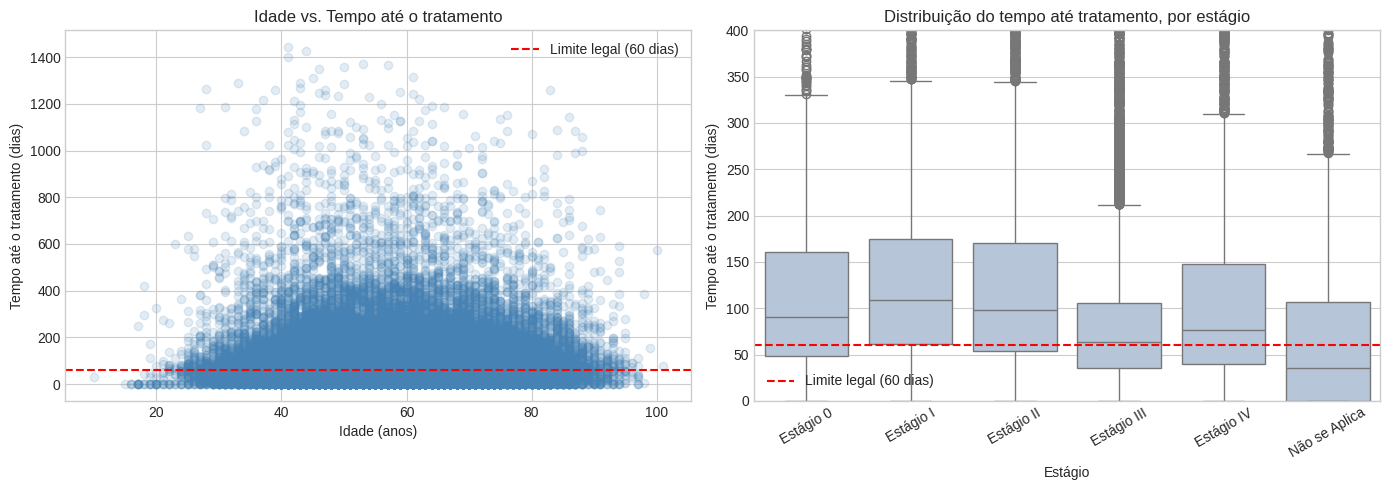

In [36]:
# ==========================================================
# 5.5.4 Idade x Tempo de tratamento (dispersão) e Estágio x Tempo (boxplot)
# ==========================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df_tempo_valido['IDADE'], df_tempo_valido['TEMPO_TRAT'], alpha=0.15, color='steelblue')
axes[0].axhline(60, color='red', linestyle='--', label='Limite legal (60 dias)')
axes[0].set_xlabel('Idade (anos)')
axes[0].set_ylabel('Tempo até o tratamento (dias)')
axes[0].set_title('Idade vs. Tempo até o tratamento')
axes[0].legend()

ordem_estagio = ['Estágio 0', 'Estágio I', 'Estágio II', 'Estágio III', 'Estágio IV', 'Não se Aplica']
sns.boxplot(data=df_tempo_valido, x='DS_ESTADIAMENTO', y='TEMPO_TRAT', order=ordem_estagio, ax=axes[1], color='lightsteelblue')
axes[1].axhline(60, color='red', linestyle='--', label='Limite legal (60 dias)')
axes[1].set_xlabel('Estágio')
axes[1].set_ylabel('Tempo até o tratamento (dias)')
axes[1].set_title('Distribuição do tempo até tratamento, por estágio')
axes[1].tick_params(axis='x', rotation=30)
axes[1].set_ylim(0, 400)
axes[1].legend()

plt.tight_layout()
plt.show()

**Interpretação:** o gráfico de dispersão não mostra um padrão linear claro entre idade e
tempo até o tratamento — os pontos estão bastante espalhados em todas as faixas etárias, o que é
coerente com a correlação fraca já observada. Já o boxplot por estágio mostra medianas de tempo
até o tratamento relativamente parecidas entre os estágios ativos (I a IV), todas **acima** da
linha do prazo legal de 60 dias — reforçando que o atraso no início do tratamento é um problema
**disseminado entre todos os estágios da doença**, e não um problema concentrado em um grupo
específico de gravidade.

### Correlação vs. causalidade

É importante deixar explícito: as associações estatísticas encontradas nesta seção (por exemplo,
entre deslocamento municipal e menor cumprimento do prazo, ou entre estágio avançado e menor
cumprimento) indicam que essas variáveis estão relacionadas, **mas não provam relação de causa e
efeito**. Diversos fatores não observados nesta base — como disponibilidade de vagas/agenda nos
serviços de oncologia, fila de espera por procedimento, gravidade clínica adicional, comorbidades
da paciente, ou mesmo diferenças na qualidade do registro entre municípios — podem estar por trás
dessas associações. O papel desta AED é **levantar hipóteses e padrões relevantes** para serem
testados de forma mais rigorosa (inclusive causal, se possível) nas próximas etapas do projeto,
não estabelecer causalidade.


## 6. Conclusão da AED

### Principais achados

1. **A base é de boa qualidade geral, com poucas mas relevantes exceções.** Após remover a coluna
   `CNS_PAC` (100% ausente) e sinalizar 765 registros (≈1,7%) com datas inconsistentes
   (`TEMPO_TRAT` negativo), o dataset ficou consistente e utilizável, com apenas ausências
   estruturalmente esperadas (residentes fora de SP, ≈3,9%), que foram tratadas com uma categoria
   explícita em vez de imputação estatística.

2. **A variável-alvo (`DS_CUMPRE_LEI_60_DIAS`) é inteiramente derivada de `TEMPO_TRAT`
   (`<=60` dias)**, que por sua vez é `DT_TRAT - DT_DIAG`. Isso é crítico para a próxima sprint:
   `TEMPO_TRAT` (e qualquer variável derivada dele) **não pode ser usado como feature preditiva**
   sem causar vazamento de dado (*data leakage*) — o modelo precisa prever o cumprimento do prazo
   **antes** de conhecer o próprio tempo de tratamento.

3. **`TEMPO_TRAT` é fortemente assimétrico à direita** (skewness ≈ 3,3), com mediana de 77 dias —
   já acima do prazo legal —, enquanto `IDADE` é aproximadamente simétrica. Isso reforça que
   medidas de tendência central baseadas em média devem ser usadas com cautela para `TEMPO_TRAT`.

4. **O desfecho está moderadamente desbalanceado:** ~60% dos casos não cumprem o prazo, contra
   ~40% que cumprem — um ponto de atenção para a escolha de métricas de avaliação e possíveis
   técnicas de balanceamento na modelagem (ex.: recall/F1 em vez de acurácia pura, ou
   reamostragem).

5. **Outliers não foram tratados de forma genérica** — distinguimos outliers que são **erros de
   dado** (tempos negativos, removidos/sinalizados) de outliers que são **o próprio fenômeno de
   interesse do projeto** (tratamentos muito demorados, mantidos na base).

6. **Dois padrões de associação com forte potencial preditivo e acionável para o negócio:**
   - Pacientes em **estágio mais avançado (IV)** têm **pior** cumprimento do prazo — o inverso do
     que seria desejável clinicamente.
   - Pacientes que precisam de **deslocamento municipal** para tratamento cumprem o prazo com
     menor frequência — evidência de barreira logística de acesso.

### Implicações para as próximas etapas (modelagem preditiva)

- **Variáveis candidatas a features:** `IDADE`, `FAIXA_ETARIA`, `DS_ESTADIAMENTO`,
  `DS_DESLOCAMENTO_MUNICIPAL`, `DS_TRATAMENTO`, geografia (`drs_TRATAM`, `rm_TRATAM`, `ra_TRATAM`,
  `municipio_RESID` vs `municipio_TRATAM` — permite derivar se residência = tratamento),
  `ANO_DIAGN`/sazonalidade, e os indicadores de contexto `CTX_*` (com a ressalva de documentação
  já registrada na seção 4).
- **Variáveis a excluir do conjunto de features** (por vazamento de dado ou ausência de
  variância): `TEMPO_TRAT`, `DT_TRAT` (pós-desfecho), `DIAGNOSTIC`, `DIAG_DETH`, `SEXO`
  (constantes).
- **Registros a excluir/segregar** para modelagem de tempo (caso seja usada uma abordagem de
  regressão do tempo, e não só classificação binária): os 765 registros com `FLAG_TEMPO_INVALIDO`.
- **Desbalanceamento de classes** deve ser considerado na escolha do modelo e das métricas de
  avaliação (ex.: matriz de confusão, F1-score, recall da classe "Não cumpre", que é a classe de
  maior interesse operacional).
- Recomendamos buscar, se possível, uma fonte oficial que documente com precisão os indicadores
  `CTX_*` do PAINEL-Oncologia antes de usá-los como features formais em modelo produtivo.


